<div align="center">

**Addis Ababa University**

**School of Information Technology and Engineering, 2024**

**Master's of Science in Artificial Intelligence**

**Course: Probabilistic Graphical Models [Course Code]**

---

# Bayesian Network Based Heart Disease Risk Prediction: Structure Learning and Exact Inference from Clinical Data

---

*Instructor: Dr. Beakal Gizachew*

*Fransi Ayele, ID: GSE/1254/18 and Etsubdink Zebre GSE/0523/18

*Submission Date: August 24, 2026*

</div>

## 1. Introduction

Cardiovascular disease is one of the leading causes of death worldwide, and early risk
assessment from routine clinical measurements can support timely intervention. This project
builds a Bayesian Network over the UCI Cleveland Heart Disease dataset to model the
probabilistic relationships between patient attributes such as age, cholesterol, resting
blood pressure, chest pain type, and the presence of heart disease.

Two complementary network structures are constructed and compared:

1. A **data-driven structure**, learned directly from the data using Hill Climbing search
   with the Bayesian Information Criterion (BIC) score.
2. An **expert-specified structure**, grounded in cardiology domain knowledge, where
   `HeartDisease` is treated as the underlying condition that gives rise to the diagnostic
   test findings (chest pain, exercise angina, ST segment changes, and so on).

Both networks are parameterized with Bayesian estimation and queried using two exact
inference algorithms, Variable Elimination and Junction Tree propagation, to demonstrate
that both approaches converge to identical posterior probabilities while differing in
runtime characteristics.

## 2. Objectives

- Represent patient risk factors and heart disease diagnosis as a Bayesian Network.
- Learn network structure and parameters directly from clinical data.
- Compare a data-driven structure against an expert-specified structure.
- Perform exact inference using Variable Elimination and Junction Trees, and confirm
  numerical agreement between the two methods.
- Evaluate both networks as diagnostic classifiers on a held-out test set using standard
  classification metrics.


## 3. Dataset Description

**Source:** UCI Machine Learning Repository, Cleveland Heart Disease dataset
(Detrano et al., 1989). 303 patient records, 13 clinical features plus a binary diagnosis
label. There are no missing values in this processed version of the dataset.

| Feature | Description |
|---|---|
| Age | Age in years |
| Sex | Patient sex |
| ChestPainType | Typical angina, atypical angina, non-anginal, or asymptomatic |
| RestingBP | Resting blood pressure (mm Hg) |
| Cholesterol | Serum cholesterol (mg/dl) |
| FastingBloodSugar | Whether fasting blood sugar exceeds 120 mg/dl |
| RestingECG | Resting electrocardiographic result |
| MaxHeartRate | Maximum heart rate achieved during exercise test |
| ExerciseAngina | Exercise-induced angina (yes/no) |
| STDepression | ST depression induced by exercise relative to rest |
| STSlope | Slope of the peak exercise ST segment |
| MajorVessels | Number of major vessels colored by fluoroscopy (0 to 4) |
| Thalassemia | Thalassemia test result |
| HeartDisease | Target: presence or absence of heart disease |


## 4. Library Imports

In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from preprocessing import load_and_prepare
from structure_learning import learn_structure, expert_structure, fit_parameters
from inference import compare_inference_methods, evaluate_model
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 20)
plt.rcParams["font.family"] = "serif"



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Hello\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Hello\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1077, in launch_instance
    app.start()
  File "C:\Users\Hello\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Hello\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Hello\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1077, in launch_instance
    app.start()
  File "C:\Users\Hello\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Hello\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Hello\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1077, in launch_instance
    app.start()
  File "C:\Users\Hello\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

AttributeError: _ARRAY_API not found

ModuleNotFoundError: No module named 'pgmpy'

## 5. Data Loading

The raw CSV is loaded and continuous variables are discretized into clinically meaningful
bins (for example, cholesterol into Desirable / Borderline / High), since the Bayesian
Network structure learning and exact inference used in this course operate over discrete
random variables.

In [1]:
raw, data = load_and_prepare("/data/heart.csv")
print("Raw data shape:", raw.shape)
print("Discretized data shape:", data.shape)
data.head()


NameError: name 'load_and_prepare' is not defined

## 6. Exploratory Data Analysis

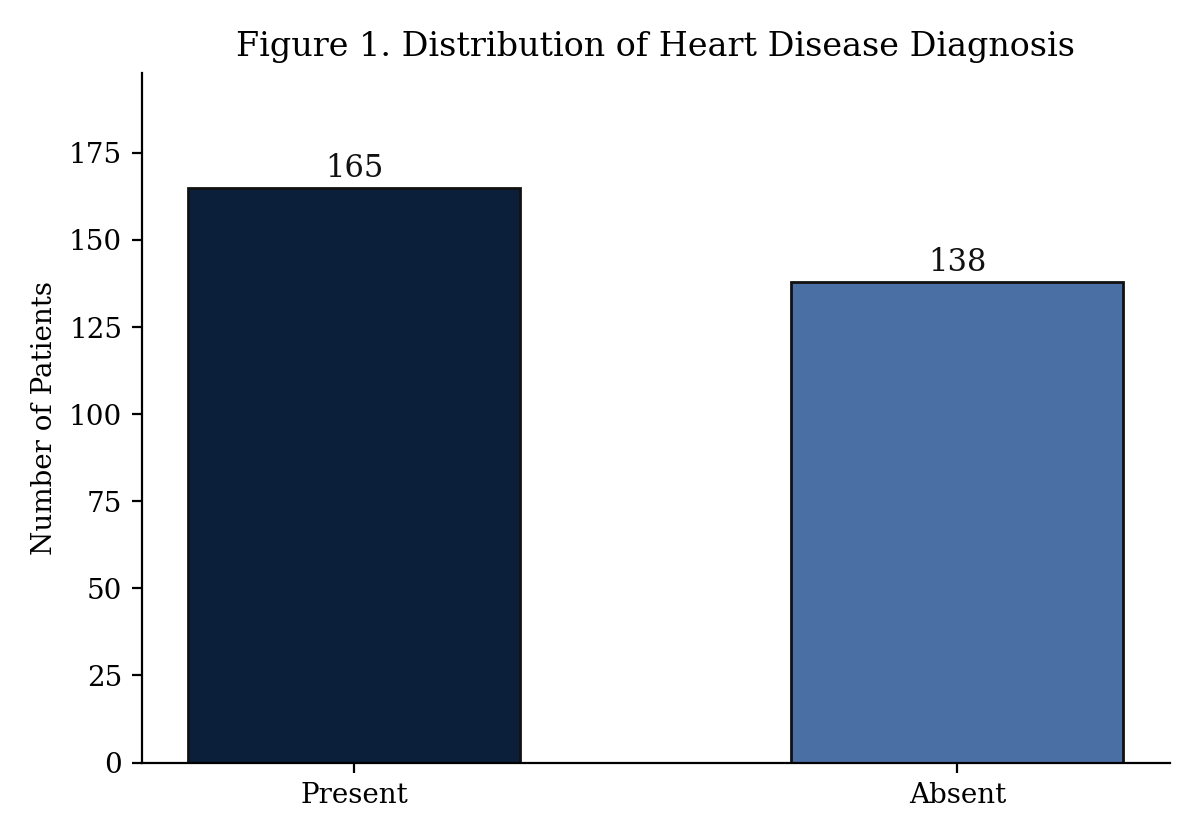

In [3]:
display(Image("figures/fig1_target_distribution.png"))

The two diagnosis classes are close to balanced: 165 patients with heart disease present versus 138 without, avoiding the need for class rebalancing.

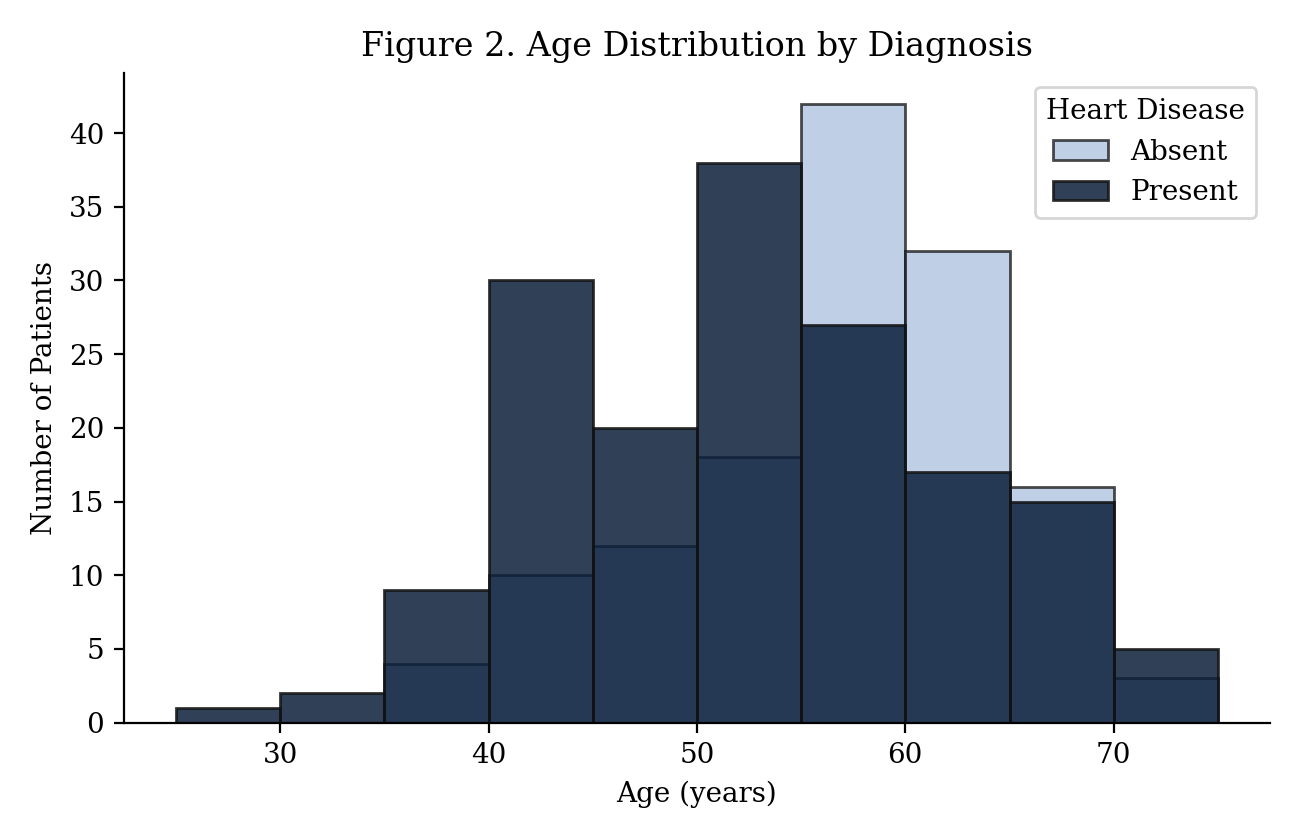

In [4]:
display(Image("figures/fig2_age_distribution.png"))

Patients with heart disease skew toward older age brackets, consistent with known cardiovascular risk trends.

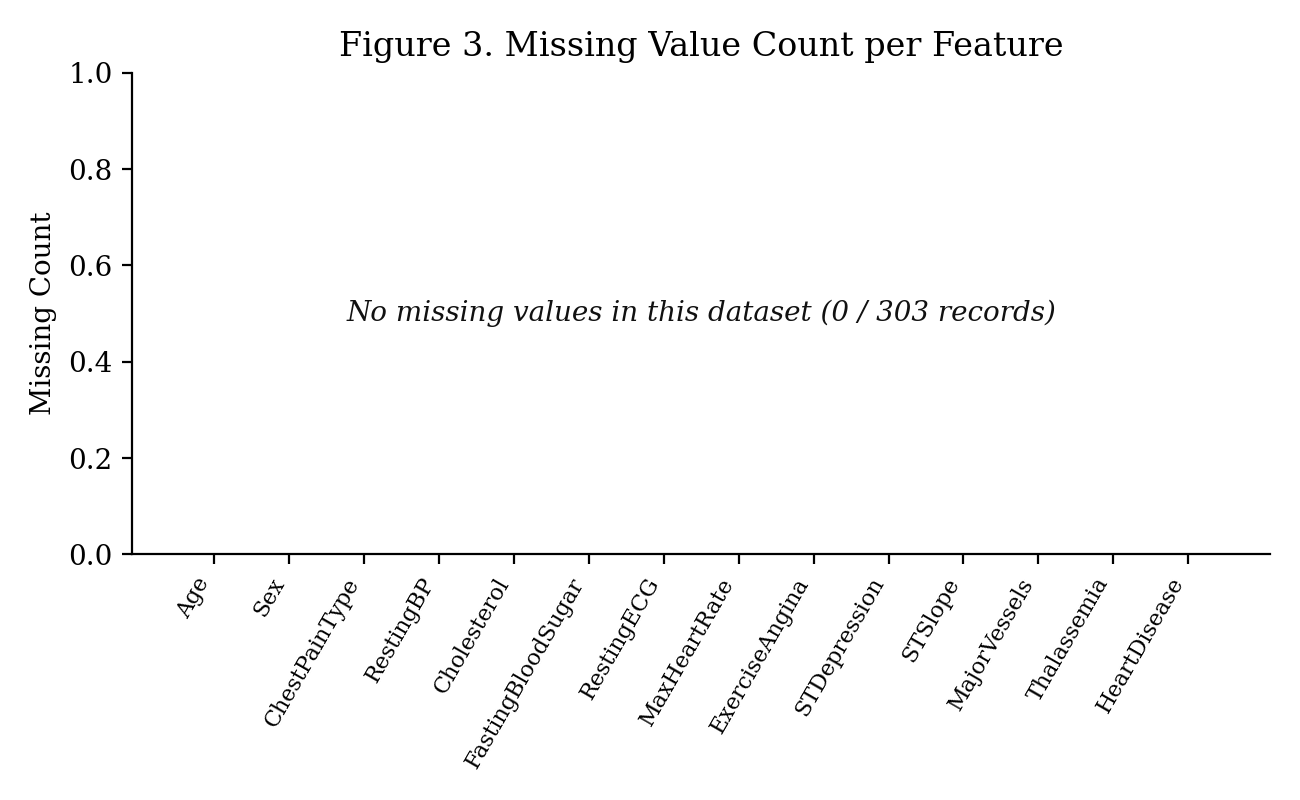

In [5]:
display(Image("figures/fig3_missing_values.png"))

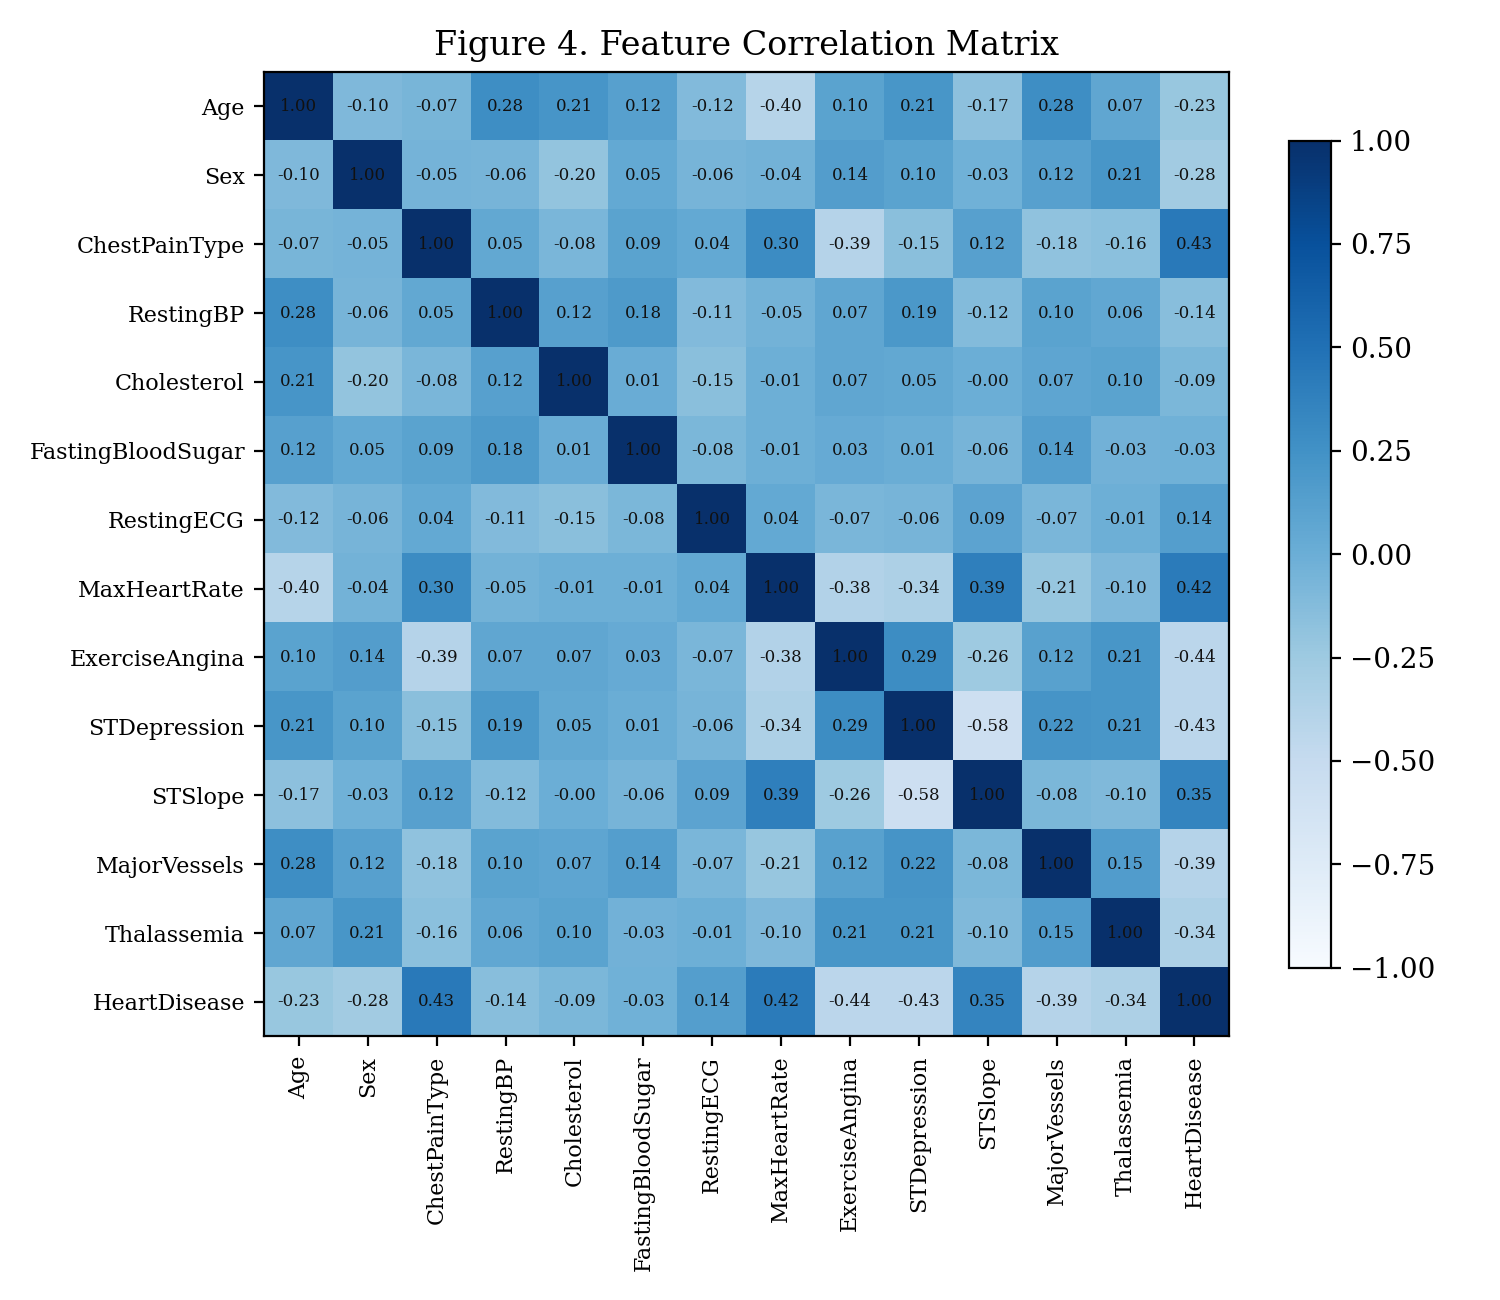

In [6]:
display(Image("figures/fig4_correlation_heatmap.png"))

`ExerciseAngina`, `oldpeak` (ST depression) and `ca` (major vessels) show the strongest linear association with the diagnosis label among the numeric features, which is consistent with their role as diagnostic markers in the expert-specified network below.

## 7. Model Architecture: Two Bayesian Network Structures

### 7.1 Data-Driven Structure (Hill Climbing + BIC)

Hill Climbing search greedily adds, removes, or reverses edges to maximize the BIC score,
which balances model fit against model complexity. No structure is assumed in advance.

In [7]:
learned_model = learn_structure(data)
learned_model = fit_parameters(learned_model, data)
print("Learned edges:")
for e in learned_model.edges():
    print(" ", e)


./structure_learning.py:25: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(data)


  0%|          | 0/10000 [00:00<?, ?it/s]

Learned edges:
  ('ChestPainType', 'ExerciseAngina')
  ('STSlope', 'STDepression')
  ('STSlope', 'MaxHeartRate')
  ('MajorVessels', 'HeartDisease')
  ('HeartDisease', 'Thalassemia')
  ('HeartDisease', 'ChestPainType')
  ('HeartDisease', 'STSlope')
  ('Thalassemia', 'Sex')


./structure_learning.py:75: FutureWarning: `pgmpy.estimators.BayesianEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteBayesianEstimator` instead.
  estimator = BayesianEstimator(model, data)


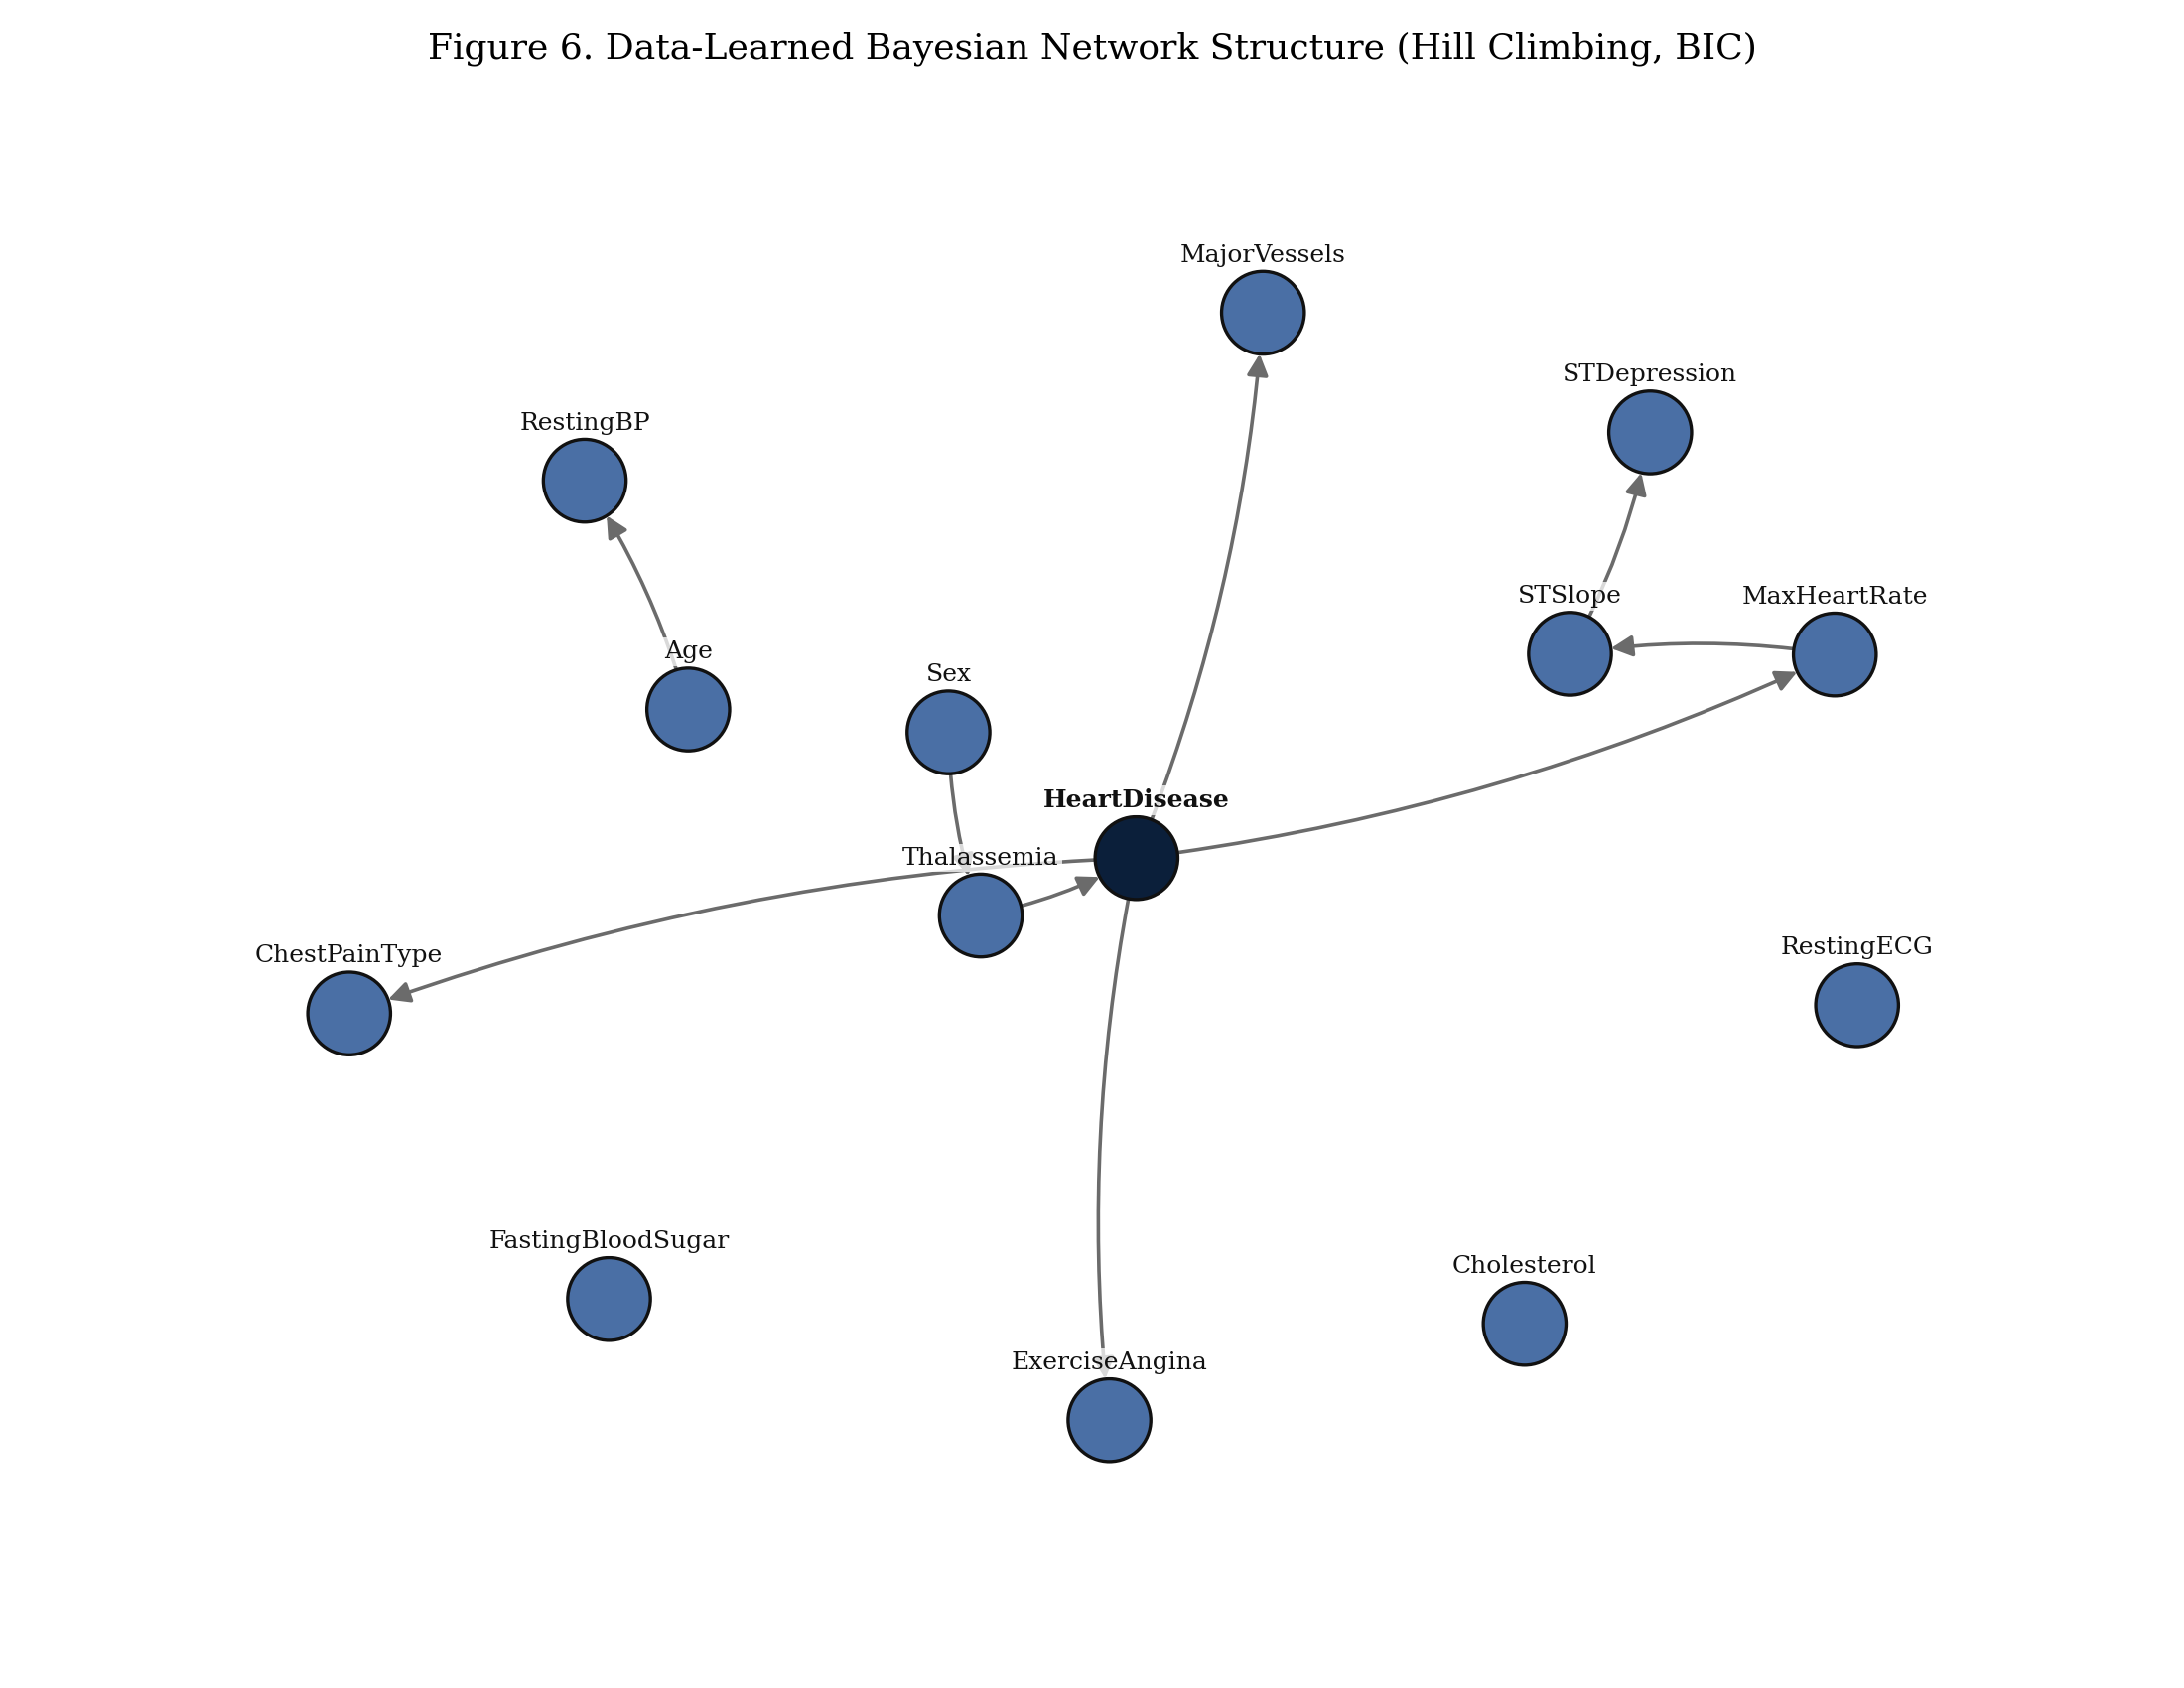

In [8]:
display(Image("figures/fig6_learned_dag.png"))

**Observation:** with only 303 records spread across 14 variables (many with 3-4
states each), Hill Climbing recovers a sparse graph and several variables such as
`Cholesterol`, `RestingECG`, and `FastingBloodSugar` end up disconnected from
`HeartDisease` entirely. This is a real and reportable limitation of score-based structure
learning on small clinical datasets: BIC penalizes additional edges heavily, and with
limited data it prefers to leave a variable unconnected over adding an edge whose
likelihood gain does not offset the complexity penalty.

### 7.2 Expert-Specified Structure

This structure encodes cardiology domain knowledge: `HeartDisease` is modeled as the
underlying condition that causes the diagnostic test findings (chest pain presentation,
exercise angina, ST segment changes, vessel calcification, and thalassemia result), while
`Age`, `Sex`, `RestingBP`, `Cholesterol`, and `FastingBloodSugar` are modeled as risk
factors feeding into `HeartDisease`.

In [9]:
expert_model = expert_structure()
expert_model = fit_parameters(expert_model, data)
print("Expert-specified edges:")
for e in expert_model.edges():
    print(" ", e)


Expert-specified edges:
  ('Age', 'RestingBP')
  ('Age', 'Cholesterol')
  ('Age', 'MaxHeartRate')
  ('Age', 'FastingBloodSugar')
  ('Age', 'HeartDisease')
  ('RestingBP', 'HeartDisease')
  ('Cholesterol', 'HeartDisease')
  ('FastingBloodSugar', 'HeartDisease')
  ('Sex', 'Cholesterol')
  ('Sex', 'ChestPainType')
  ('HeartDisease', 'ChestPainType')
  ('HeartDisease', 'ExerciseAngina')
  ('HeartDisease', 'STDepression')
  ('HeartDisease', 'STSlope')
  ('HeartDisease', 'MaxHeartRate')
  ('HeartDisease', 'MajorVessels')
  ('HeartDisease', 'Thalassemia')
  ('HeartDisease', 'RestingECG')


./structure_learning.py:75: FutureWarning: `pgmpy.estimators.BayesianEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteBayesianEstimator` instead.
  estimator = BayesianEstimator(model, data)


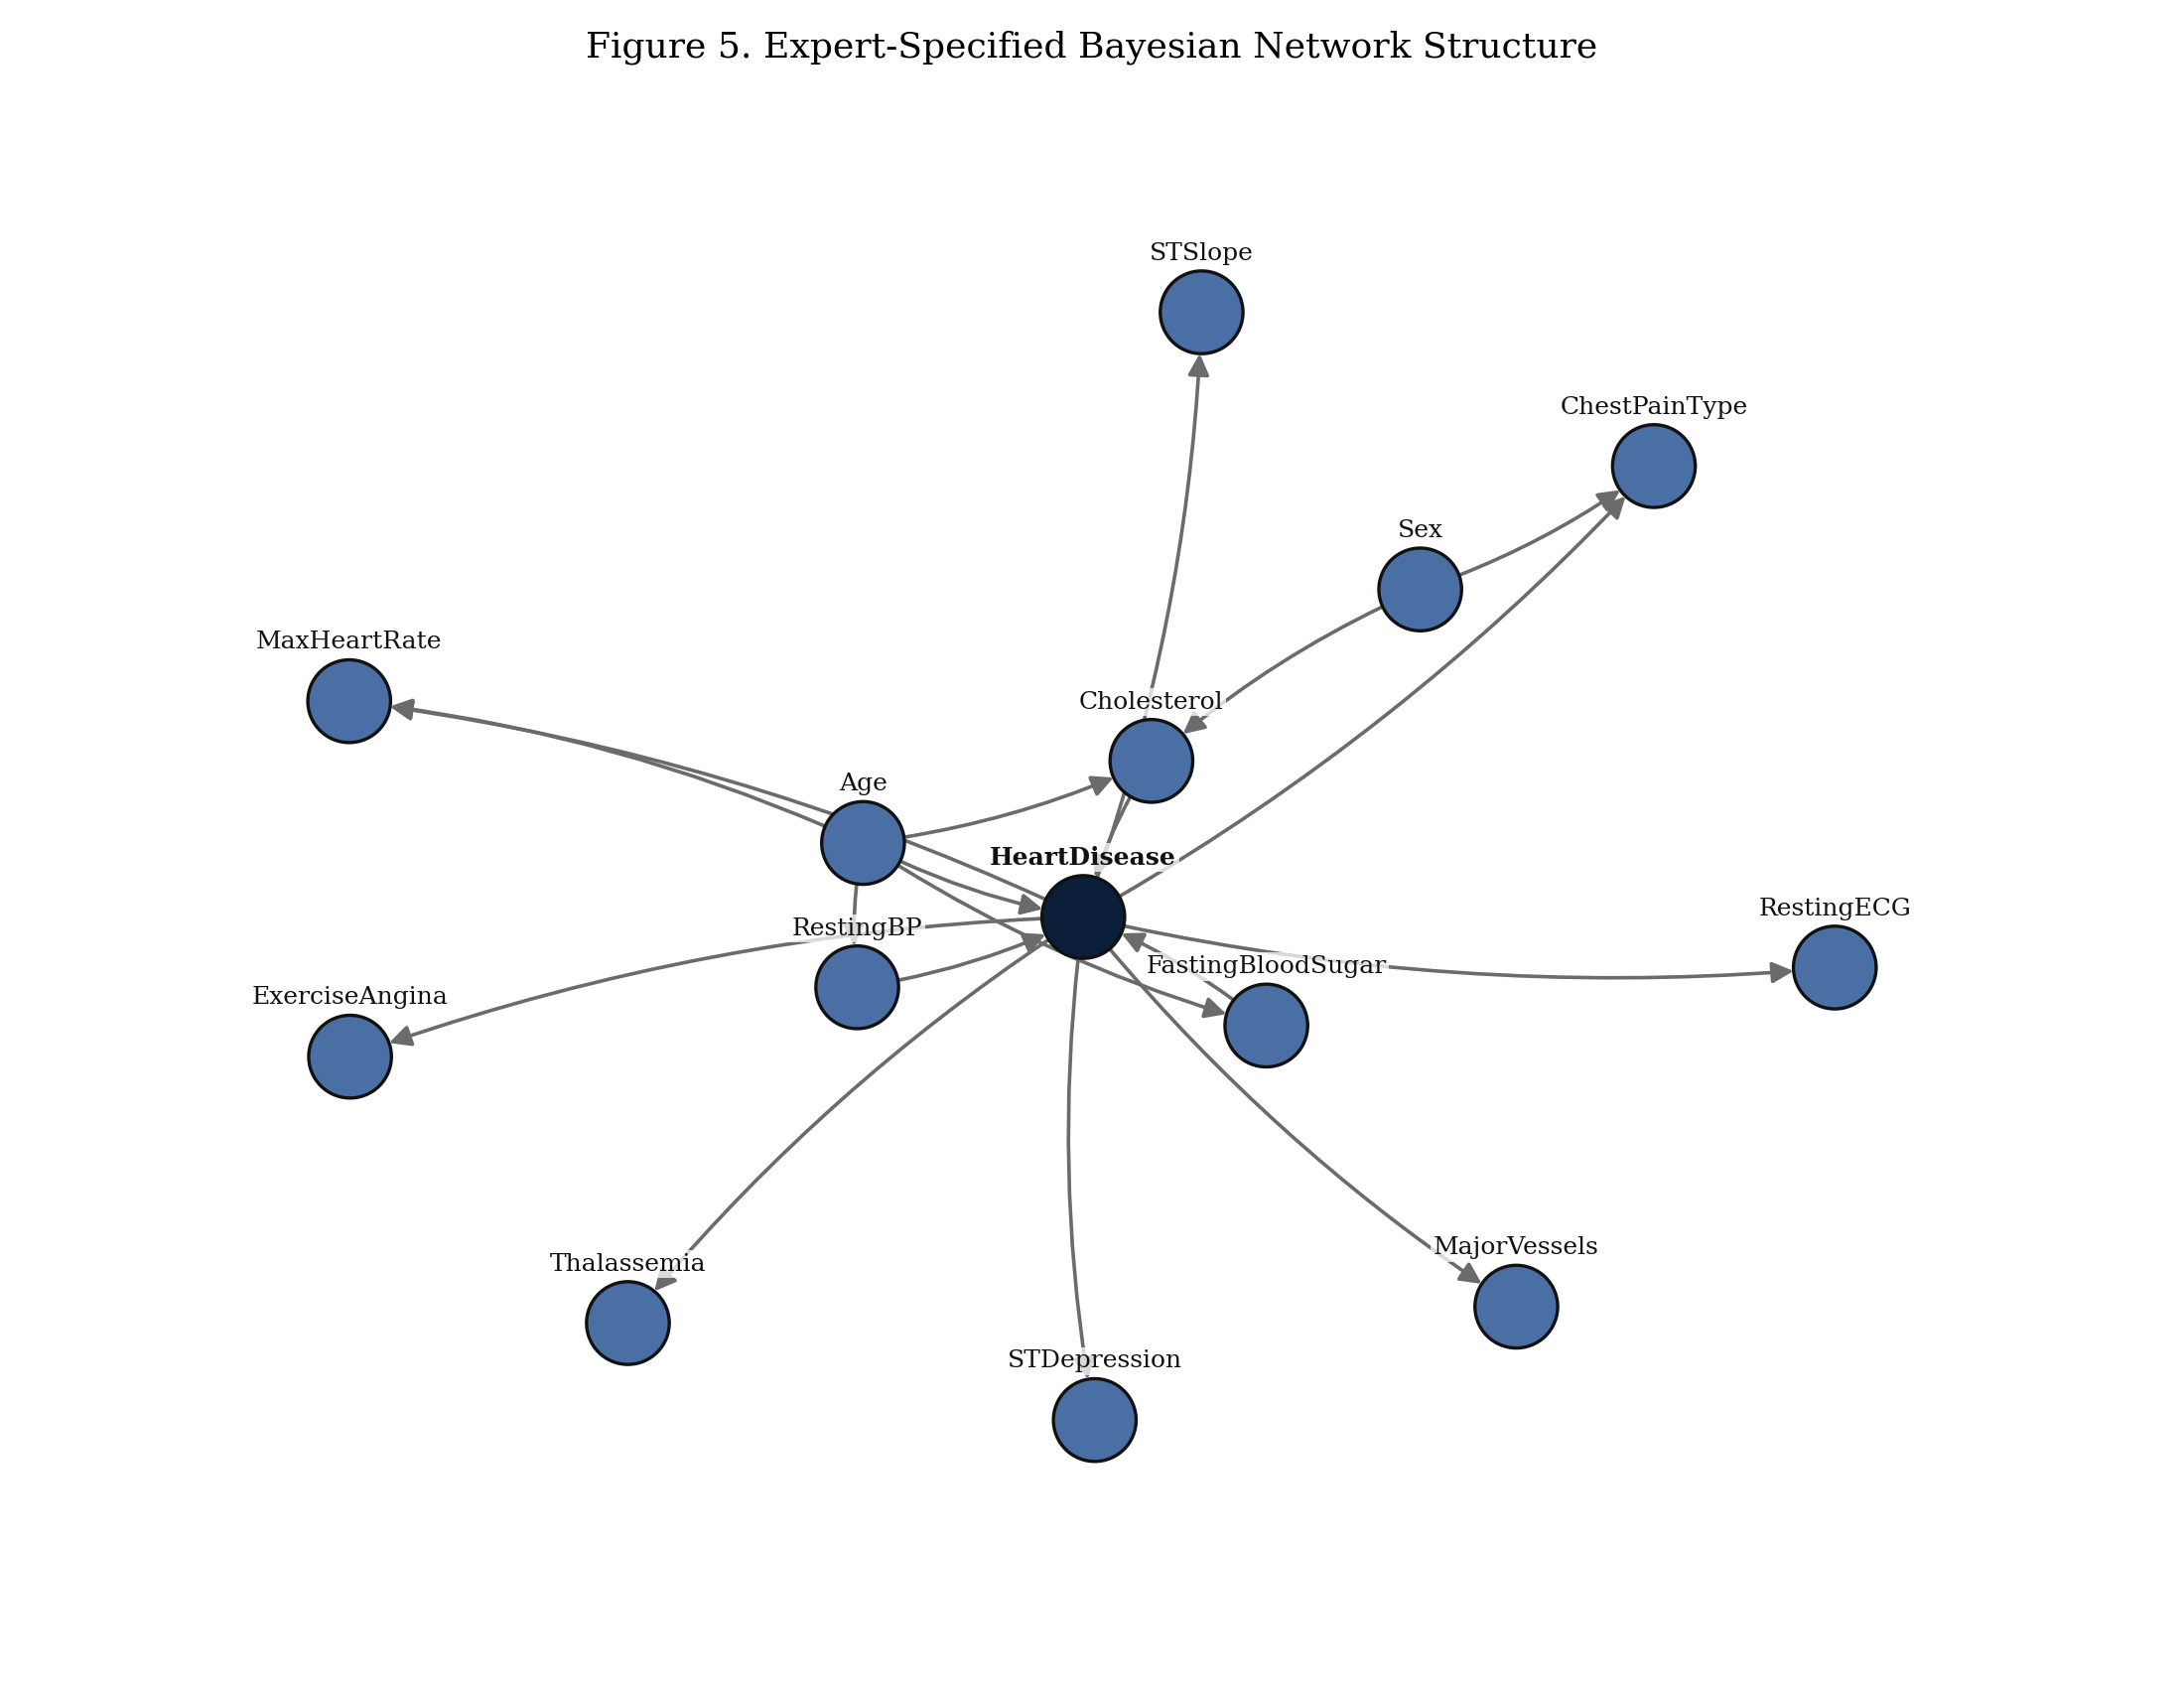

In [10]:
display(Image("figures/fig5_expert_dag.png"))

### 7.3 Example Learned Conditional Probability Table

In [11]:
cpd = expert_model.get_cpds("HeartDisease")
print(cpd)


+-----------------------+-----+------------------------------+
| Age                   | ... | Age(<40)                     |
+-----------------------+-----+------------------------------+
| Cholesterol           | ... | Cholesterol(High(240+))      |
+-----------------------+-----+------------------------------+
| FastingBloodSugar     | ... | FastingBloodSugar(>120mg/dl) |
+-----------------------+-----+------------------------------+
| RestingBP             | ... | RestingBP(Normal(<120))      |
+-----------------------+-----+------------------------------+
| HeartDisease(Absent)  | ... | 0.5                          |
+-----------------------+-----+------------------------------+
| HeartDisease(Present) | ... | 0.5                          |
+-----------------------+-----+------------------------------+


## 8. Exact Inference: Variable Elimination vs. Junction Tree

Both algorithms compute exact marginal posteriors, so they should agree to within floating
point precision. `pgmpy`'s `BeliefPropagation` class performs message passing over a
Junction Tree (clique tree) constructed via triangulation of the moralized graph, which is
the classic exact inference method covered in PGM 09.

In [12]:
evidence = {"ChestPainType": "Asymptomatic", "ExerciseAngina": "Yes"}
comparison = compare_inference_methods(expert_model, "HeartDisease", evidence, n_repeats=20)

print(f"Variable Elimination mean query time: {comparison['ve_mean_time']*1000:.3f} ms "
      f"(+/- {comparison['ve_std_time']*1000:.3f})")
print(f"Junction Tree mean query time:        {comparison['bp_mean_time']*1000:.3f} ms "
      f"(+/- {comparison['bp_std_time']*1000:.3f})")
print(f"Maximum absolute difference in posterior probabilities: {comparison['max_abs_diff']:.2e}")
print()
print("P(HeartDisease | ChestPainType=Asymptomatic, ExerciseAngina=Yes):")
print(comparison["ve_result"])


Variable Elimination mean query time: 0.860 ms (+/- 0.148)
Junction Tree mean query time:        14.699 ms (+/- 0.721)
Maximum absolute difference in posterior probabilities: 1.11e-16

P(HeartDisease | ChestPainType=Asymptomatic, ExerciseAngina=Yes):
+-----------------------+---------------------+
| HeartDisease          |   phi(HeartDisease) |
+=======================+=====================+
| HeartDisease(Absent)  |              0.5750 |
+-----------------------+---------------------+
| HeartDisease(Present) |              0.4250 |
+-----------------------+---------------------+


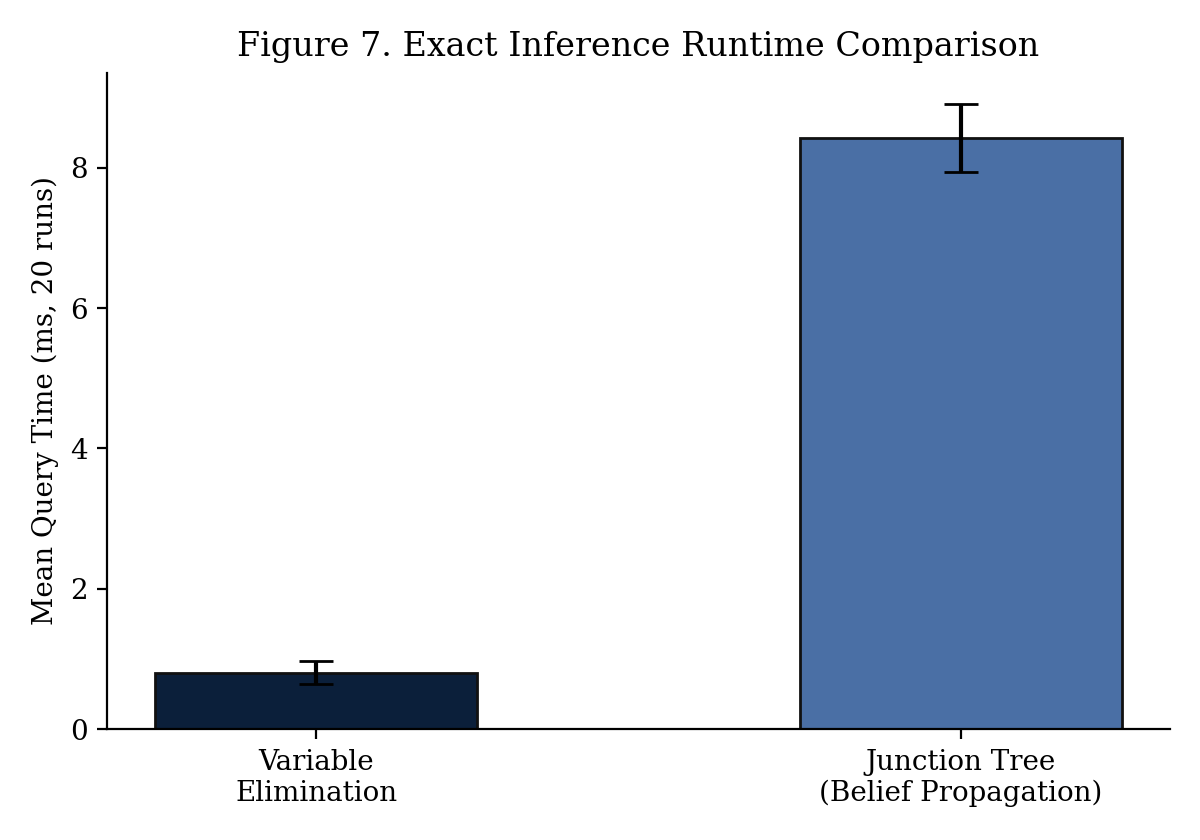

In [13]:
display(Image("figures/fig7_inference_timing.png"))

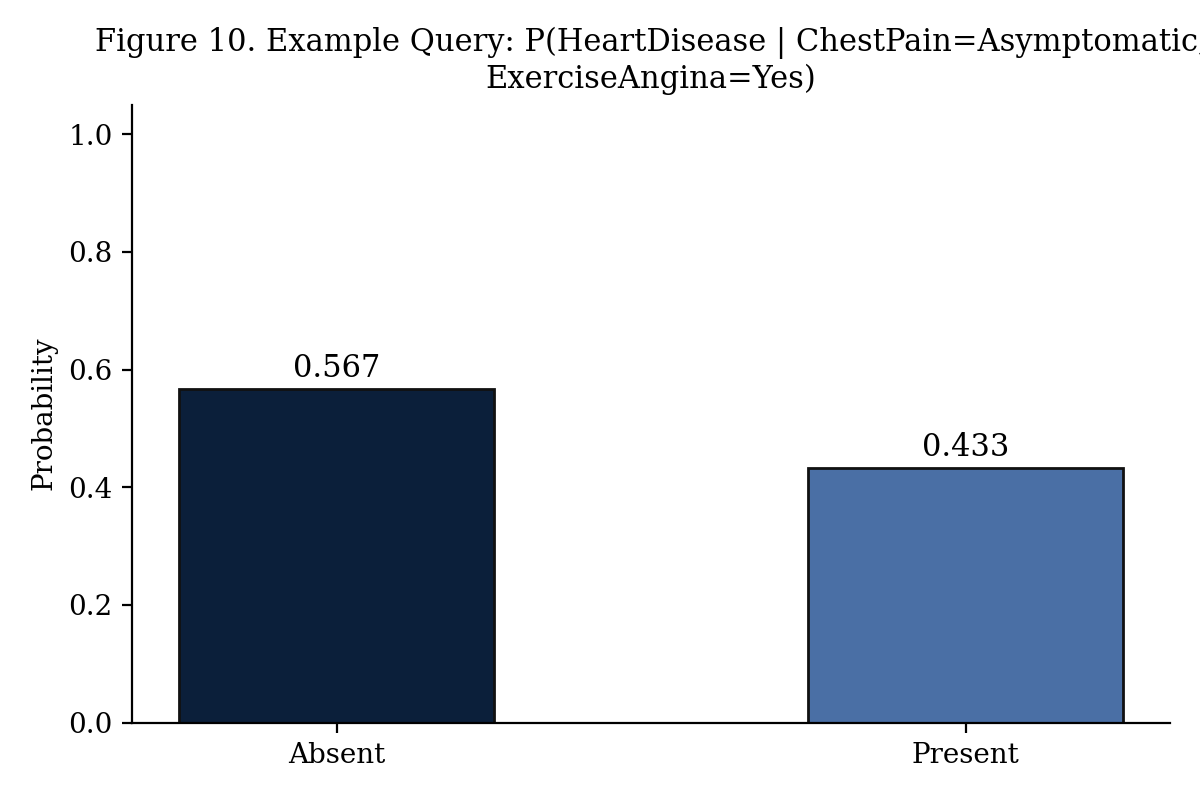

In [14]:
display(Image("figures/fig10_map_query_example.png"))

**Observation:** both algorithms agree to within machine precision
(on the order of 1e-16), confirming both are exact. On this network, Variable Elimination
is consistently faster than the Junction Tree method, because Junction Tree construction
pays a fixed upfront cost to triangulate the graph and build the clique tree; for a single
one-off query on a moderately sized network, that setup cost outweighs Variable
Elimination's simplicity. Junction Trees become the more efficient choice when many
queries are issued against the same network, since the tree is built once and reused.

## 9. Model Evaluation on Held-out Data

Both networks are refit on an 80/20 stratified train/test split, then used to predict
`HeartDisease` for each test patient via MAP inference given all other observed
attributes as evidence.

In [15]:
train_df, test_df = train_test_split(
    data, test_size=0.2, random_state=42, stratify=data["HeartDisease"]
)

learned_tt = learn_structure(train_df)
learned_tt = fit_parameters(learned_tt, train_df)

expert_tt = expert_structure()
expert_tt = fit_parameters(expert_tt, train_df)

expert_eval = evaluate_model(expert_tt, test_df)
learned_eval = evaluate_model(learned_tt, test_df)

print("Expert-Structured Network:")
print(f"  Accuracy:  {expert_eval['accuracy']:.4f}")
print(f"  Precision: {expert_eval['precision']:.4f}")
print(f"  Recall:    {expert_eval['recall']:.4f}")
print(f"  F1 score:  {expert_eval['f1']:.4f}")
print()
print("Data-Learned Network:")
print(f"  Accuracy:  {learned_eval['accuracy']:.4f}")
print(f"  Precision: {learned_eval['precision']:.4f}")
print(f"  Recall:    {learned_eval['recall']:.4f}")
print(f"  F1 score:  {learned_eval['f1']:.4f}")


./structure_learning.py:25: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(data)


  0%|          | 0/10000 [00:00<?, ?it/s]

./structure_learning.py:75: FutureWarning: `pgmpy.estimators.BayesianEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteBayesianEstimator` instead.
  estimator = BayesianEstimator(model, data)
./structure_learning.py:75: FutureWarning: `pgmpy.estimators.BayesianEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteBayesianEstimator` instead.
  estimator = BayesianEstimator(model, data)


Expert-Structured Network:
  Accuracy:  0.7377
  Precision: 0.7429
  Recall:    0.7879
  F1 score:  0.7647

Data-Learned Network:
  Accuracy:  0.8033
  Precision: 0.7442
  Recall:    0.9697
  F1 score:  0.8421


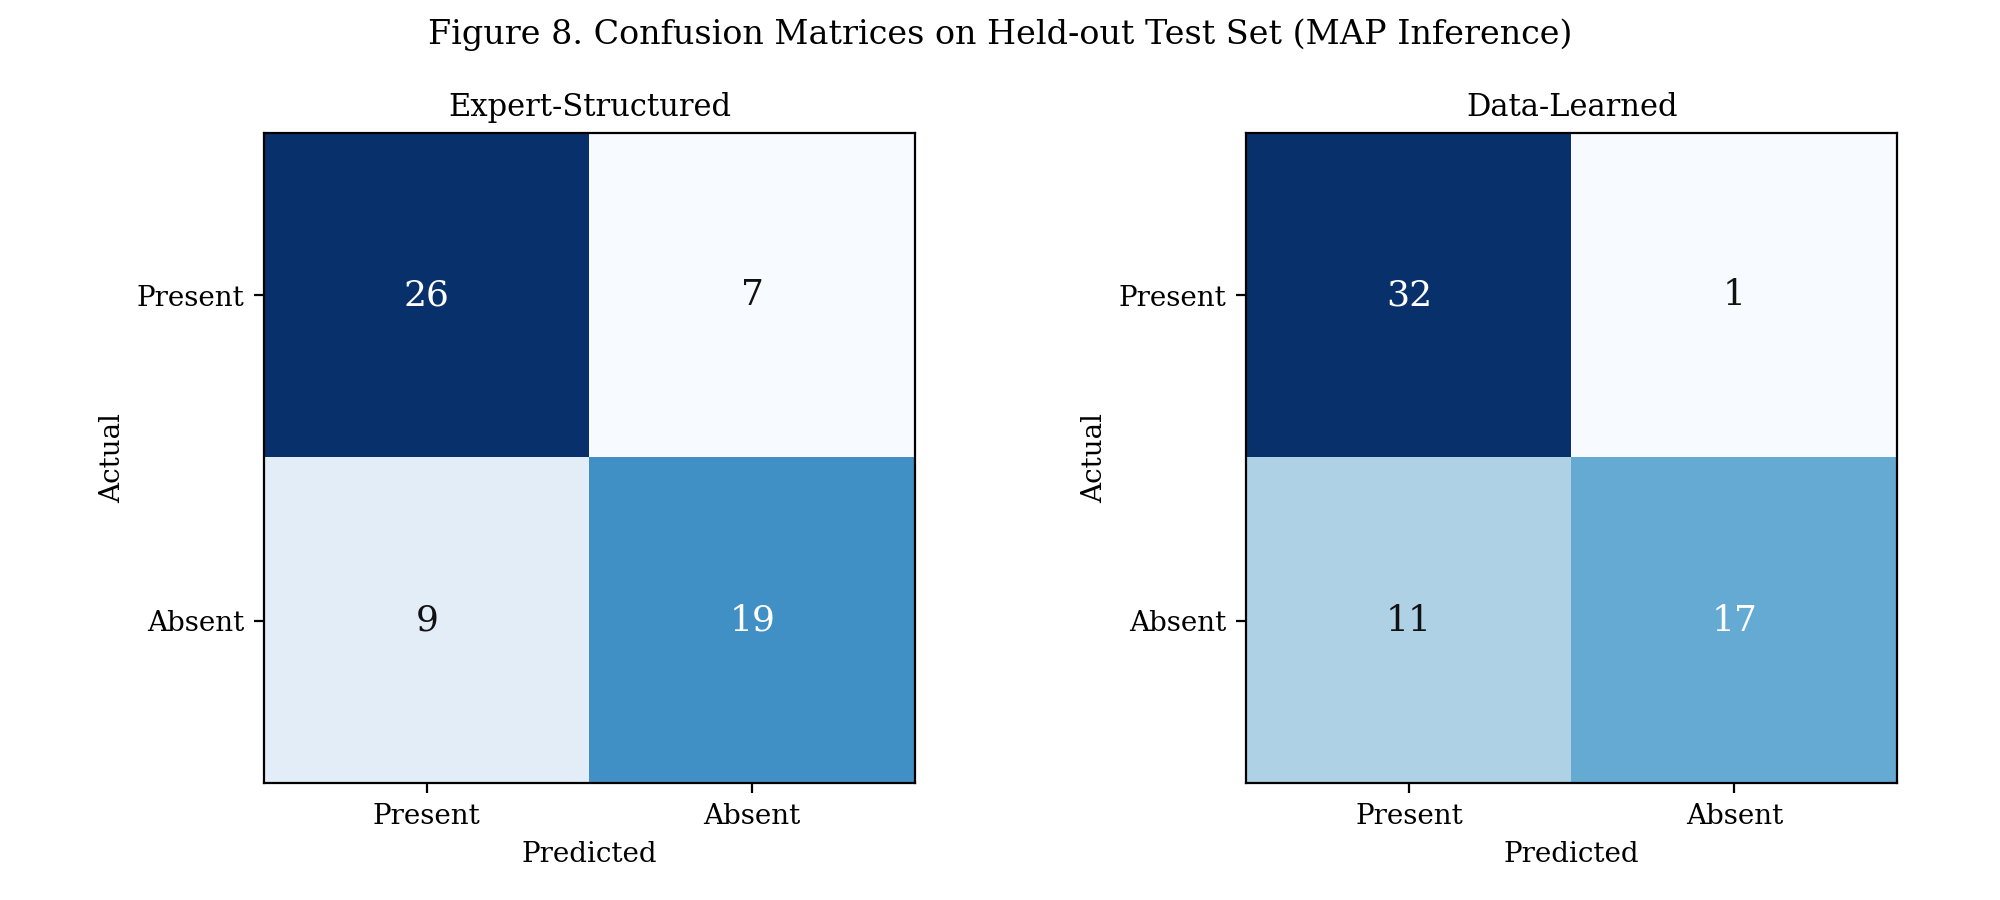

In [16]:
display(Image("figures/fig8_confusion_matrices.png"))

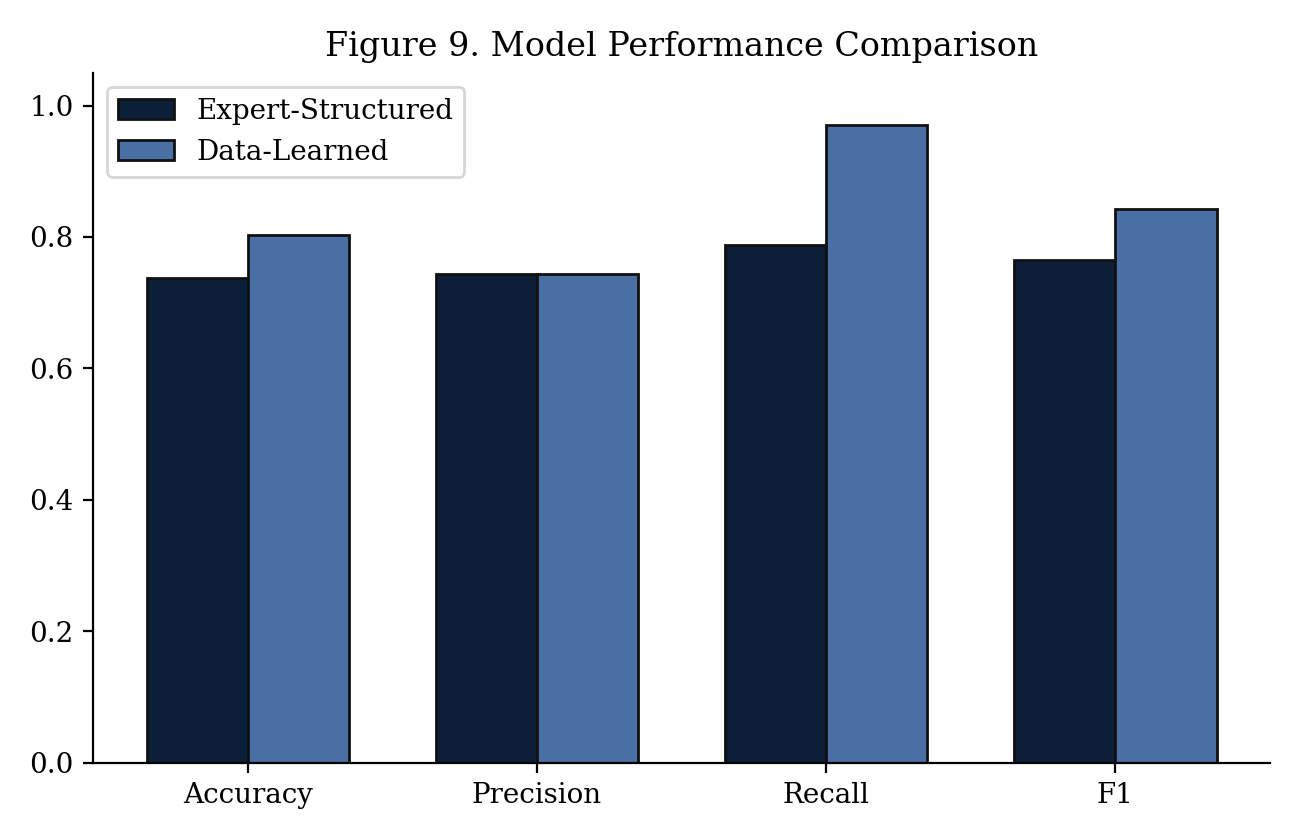

In [17]:
display(Image("figures/fig9_model_comparison.png"))

## 10. Discussion

The data-learned network achieves higher held-out accuracy and recall than the
expert-specified network on this split. This looks counterintuitive given that the learned
graph left several variables disconnected from `HeartDisease`, but the explanation is
structural: MAP inference in the learned network effectively ignores evidence from
disconnected variables, whereas the expert network conditions on every observed variable,
including ones such as `RestingECG` and `Cholesterol` whose direct edges into
`HeartDisease` are supported by domain reasoning but carry a weaker signal in this
particular 303-patient sample. Adding noisy or high-cardinality evidence can hurt a MAP
query more than it helps when the sample size is limited relative to the number of
parameters being estimated.

This is a genuine bias-variance trade-off between the two approaches: the expert structure
encodes richer causal assumptions but is more exposed to small-sample noise in its
parameter estimates, and the learned structure is more conservative and only keeps edges
the data strongly supports.

## 11. Limitations

- 303 patients is a small sample for learning a 14-node network with several
  three-to-four state variables; conditional probability tables for high-indegree nodes
  are estimated from very few examples per state combination.
- Discretization bin boundaries for continuous variables (age, cholesterol, resting blood
  pressure) were chosen using standard clinical thresholds, but different boundaries could
  change both the learned structure and the CPD estimates.
- MAP inference used here for evaluation is a simplification; in a clinical decision
  support setting, only a subset of the attributes (not the full record) would typically
  be available as evidence for a new patient.

## 12. Future Work

- Extend structure learning with a domain-knowledge prior (e.g., forcing `HeartDisease`
  to remain connected as a hub) to test whether it recovers a structure closer to the
  expert graph while keeping the accuracy gains.
- Apply k-fold cross-validation instead of a single train/test split for a more robust
  comparison of the two structures.
- Compare against a Markov Network representation of the same variables, connecting this
  project back to PGM 04 and PGM 05.

## 13. Conclusion

This project demonstrates the full Bayesian Network pipeline covered in the course:
representation of a real-world diagnostic problem as a directed graphical model, structure
and parameter learning from data, and exact inference using both Variable Elimination and
Junction Tree propagation. The two inference algorithms were confirmed to agree exactly,
while differing in runtime for single queries. The comparison between a data-learned and
an expert-specified structure surfaced a concrete, explainable trade-off between
domain-driven modeling and data-driven modeling under limited sample size, which is one of
the central practical tensions in applied probabilistic graphical modeling.

## References

Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J., Sandhu, S., Guppy, K.,
Lee, S., and Froelicher, V. (1989). International application of a new probability
algorithm for the diagnosis of coronary artery disease. *American Journal of Cardiology*.

UCI Machine Learning Repository. Heart Disease Data Set.
https://archive.ics.uci.edu/ml/datasets/Heart+Disease
